In [27]:
import os
import sys
import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgbm

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from hyperopt import hp

from utils import user_utils
from utils import preprocessing
from utils import data_sampling
from utils import modeling

In [28]:
raw_df = pd.read_csv('../data/creditcard.csv')

In [29]:
X_features, y_target = preprocessing.split_features_target(raw_df, cols= 'Time')

In [30]:
cap_X_feature = preprocessing.cap_outliers(X_features)

In [18]:
X_train, X_test, y_train, y_test = preprocessing.data_split(cap_X_feature, y_target)
X_tr, X_val, y_tr, y_val = preprocessing.data_split(X_train, y_train, size=0.4)

In [31]:
# 결과받을 딕셔너리
results = {}

In [20]:
tuner = user_utils.HyperOptTuner(max_evals=100, random_state=23)

# RandomForest 예시
catboost_search_space = {
        'iterations': hp.quniform('iterations', 100, 1000, 50),
        'depth': hp.quniform('depth', 4, 10, 1),  
        'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),  
        'l2_leaf_reg': hp.loguniform('l2_leaf_reg', np.log(1), np.log(10)),  
        'border_count': hp.choice('border_count', [32, 64, 128, 254]),  
        'bagging_temperature': hp.uniform('bagging_temperature', 0, 1),  
        'random_strength': hp.uniform('random_strength', 0, 10)  
    }
dt_search_space = {
        'criterion': hp.choice('criterion', ['gini', 'entropy']),
        'max_depth': hp.quniform('max_depth', 5, 20, 1),
        'min_samples_split': hp.quniform('min_samples_split', 2, 50, 2),
        'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 20, 1), 
        'max_features': hp.choice('max_features', ['sqrt', 'log2', None]),
        'min_impurity_decrease': hp.uniform('min_impurity_decrease', 0, 0.01)
    }

catboost = CatBoostClassifier()
dt_clf = DecisionTreeClassifier()

best_params, best_catboost, trials, exec_time = tuner.tune(
    catboost, X_tr, y_tr, X_val, y_val, catboost_search_space
    )

model_name = 'cb_ho_best'
results[model_name] = user_utils.get_model_train_eval(
    best_catboost, model_name, X_train, X_test, y_train, y_test, best_params
    )



CatBoostClassifier 튜닝 시작
100%|██████████| 100/100 [25:24<00:00, 15.25s/trial, best loss: -0.9874709561984689]

튜닝 시간: 1524.63초
최적 roc_auc: 0.9875

최적 모델의 전체 평가 점수:
- roc_auc: 0.9875
- f1: 0.8432
- precision: 0.9380
- recall: 0.7658
- accuracy: 0.9995
✓ 모델 저장 완료: ../models\cb_ho_best.pkl
  파일 크기: 0.90 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9707, '정확도': 0.9996, '정밀도': 0.9639, '재현율': 0.8163, 'F1': 0.8840 }
{'오차행렬':
[[56861     3]
 [   18    80]] }
실행 시간: 25.6335666179657
하이퍼파라미터: {'bagging_temperature': 0.9785064406120697, 'border_count': 128, 'depth': 6, 'iterations': 850, 'l2_leaf_reg': 2.40870230306742, 'learning_rate': 0.04375728432712771, 'random_strength': 5.812907782545954, 'random_state': 23, 'verbose': 0, 'allow_writing_files': False}


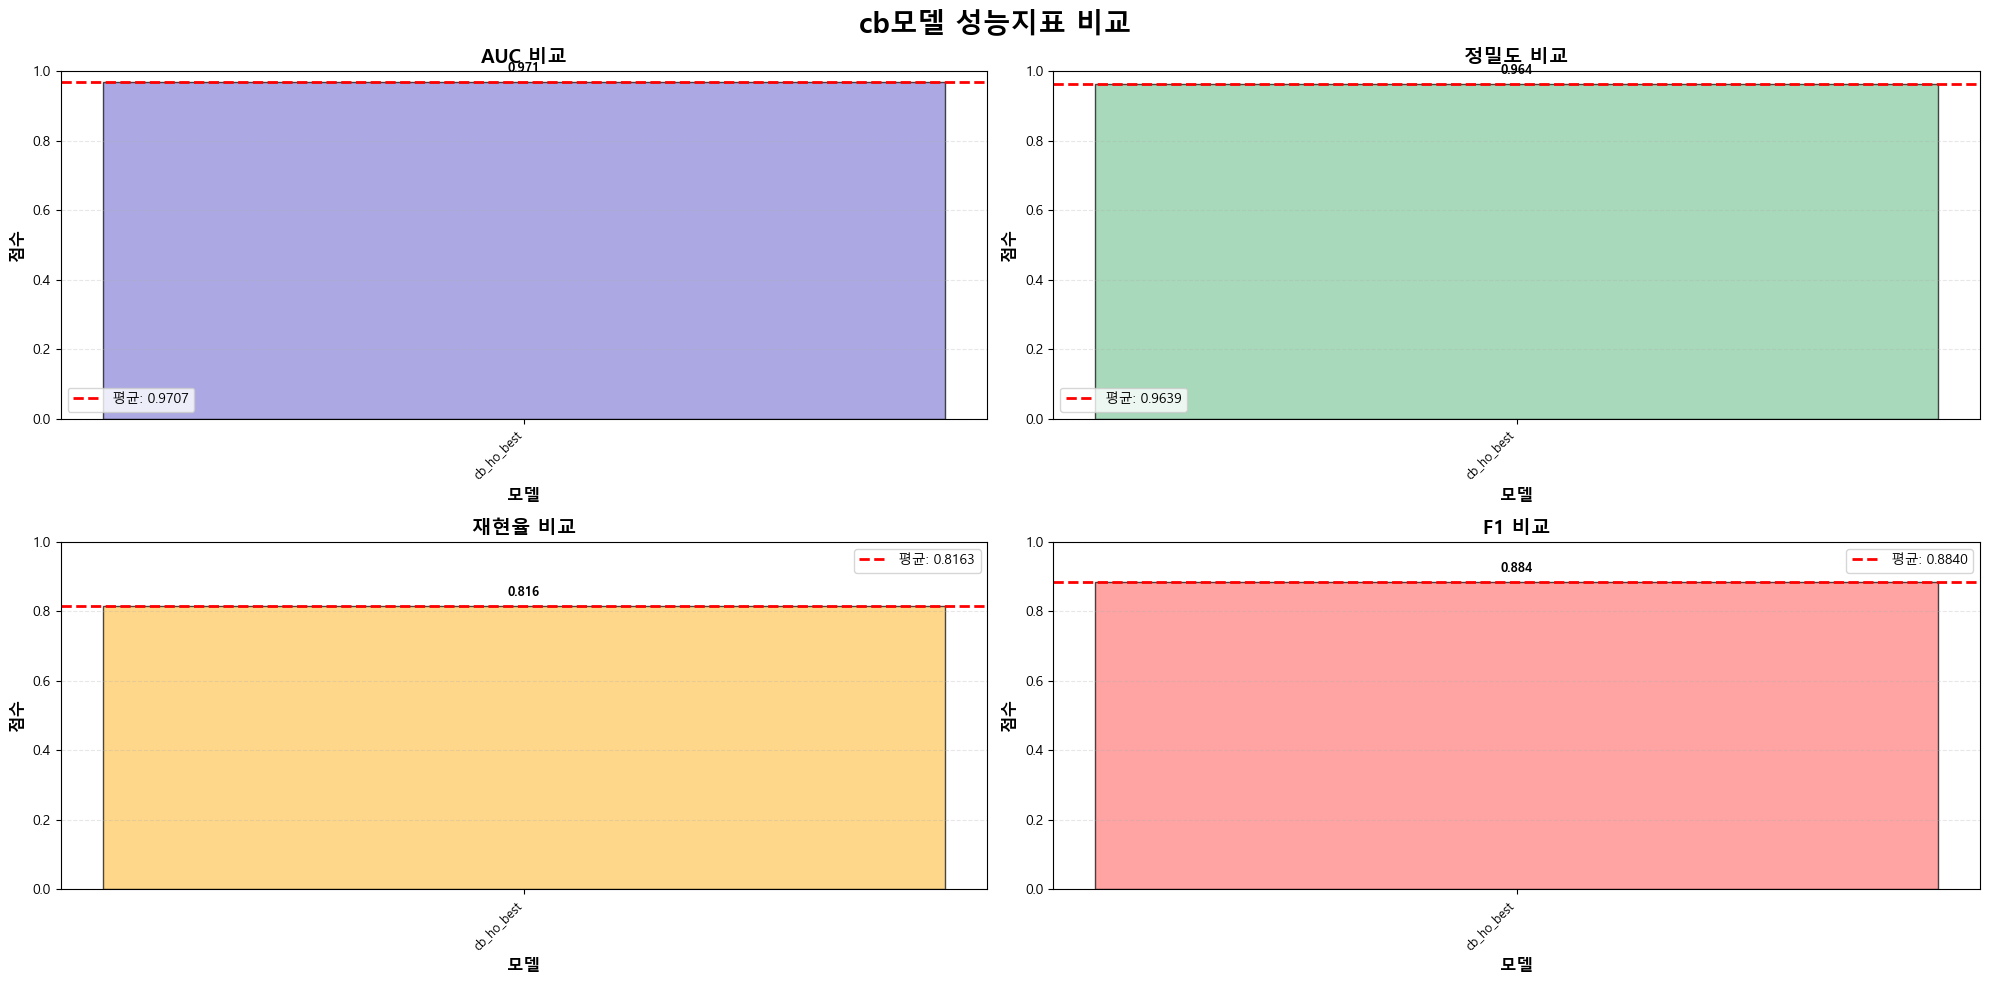


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9707 (cb_ho_best)
  최저: 0.9707 (cb_ho_best)
  평균: 0.9707
  표준편차: nan

[정밀도]
  최고: 0.9639 (cb_ho_best)
  최저: 0.9639 (cb_ho_best)
  평균: 0.9639
  표준편차: nan

[재현율]
  최고: 0.8163 (cb_ho_best)
  최저: 0.8163 (cb_ho_best)
  평균: 0.8163
  표준편차: nan

[F1]
  최고: 0.8840 (cb_ho_best)
  최저: 0.8840 (cb_ho_best)
  평균: 0.8840
  표준편차: nan


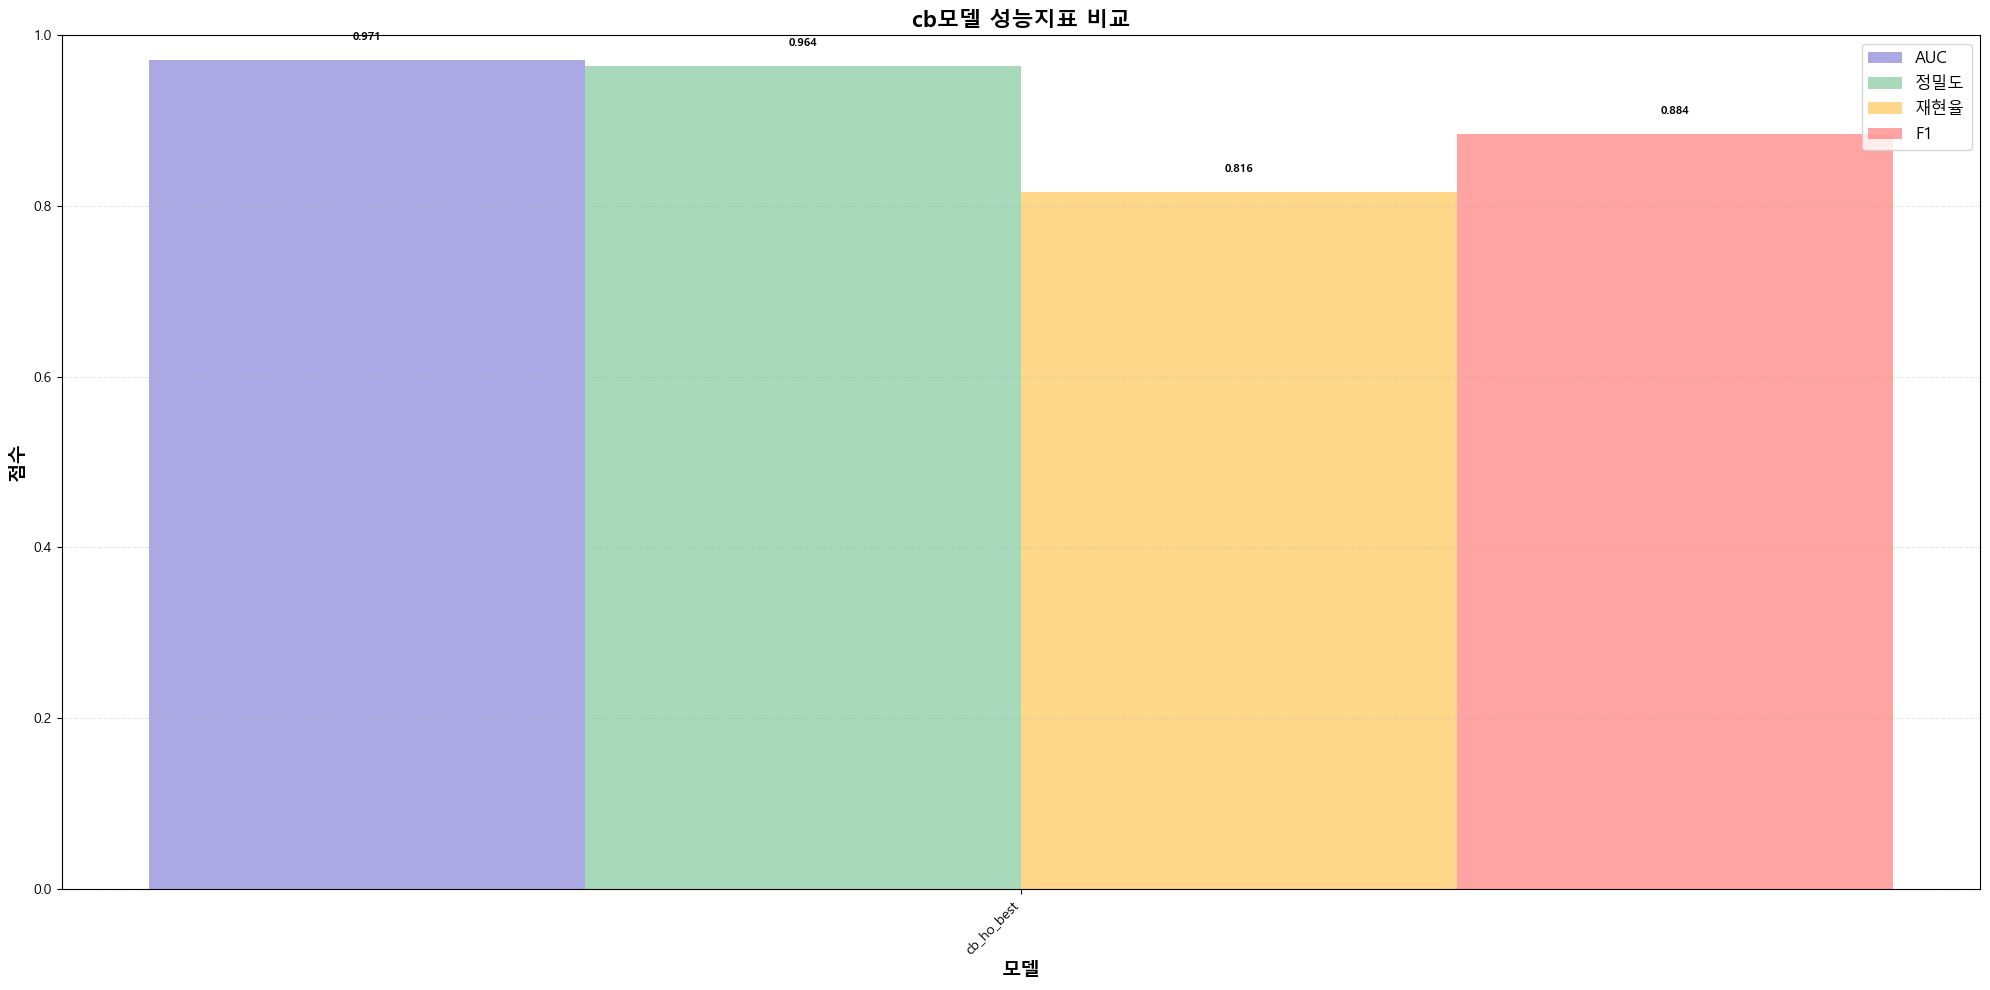


=== F1 Score 기준 상위 5개 모델 ===
               AUC     정밀도     재현율     F1
cb_ho_best  0.9707  0.9639  0.8163  0.884

=== AUC 기준 상위 5개 모델 ===
               AUC     정밀도     재현율     F1
cb_ho_best  0.9707  0.9639  0.8163  0.884

그래프가 저장되었습니다: ../images/cb모델_성능지표_비교_2025_1130.png


In [21]:
modeling.model_metrics_graph(results, 'cb모델 성능지표 비교')

In [22]:
best_params, best_dt, trials, exec_time = tuner.tune(
    dt_clf, X_tr, y_tr, X_val, y_val, dt_search_space
    )

model_name = 'dt_ho_best'
results[model_name] = user_utils.get_model_train_eval(
    best_dt, model_name, X_train, X_test, y_train, y_test, best_params
    )


DecisionTreeClassifier 튜닝 시작
100%|██████████| 100/100 [01:02<00:00,  1.60trial/s, best loss: -0.9362302119536634]

튜닝 시간: 62.70초
최적 roc_auc: 0.9362

최적 모델의 전체 평가 점수:
- roc_auc: 0.9362
- f1: 0.7301
- precision: 0.7083
- recall: 0.7532
- accuracy: 0.9990
✓ 모델 저장 완료: ../models\dt_ho_best.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9179, '정확도': 0.9992, '정밀도': 0.7907, '재현율': 0.6939, 'F1': 0.7391 }
{'오차행렬':
[[56846    18]
 [   30    68]] }
실행 시간: 0.8634541034698486
하이퍼파라미터: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'log2', 'min_impurity_decrease': 0.0002503185521839207, 'min_samples_leaf': 3, 'min_samples_split': 32, 'random_state': 23}


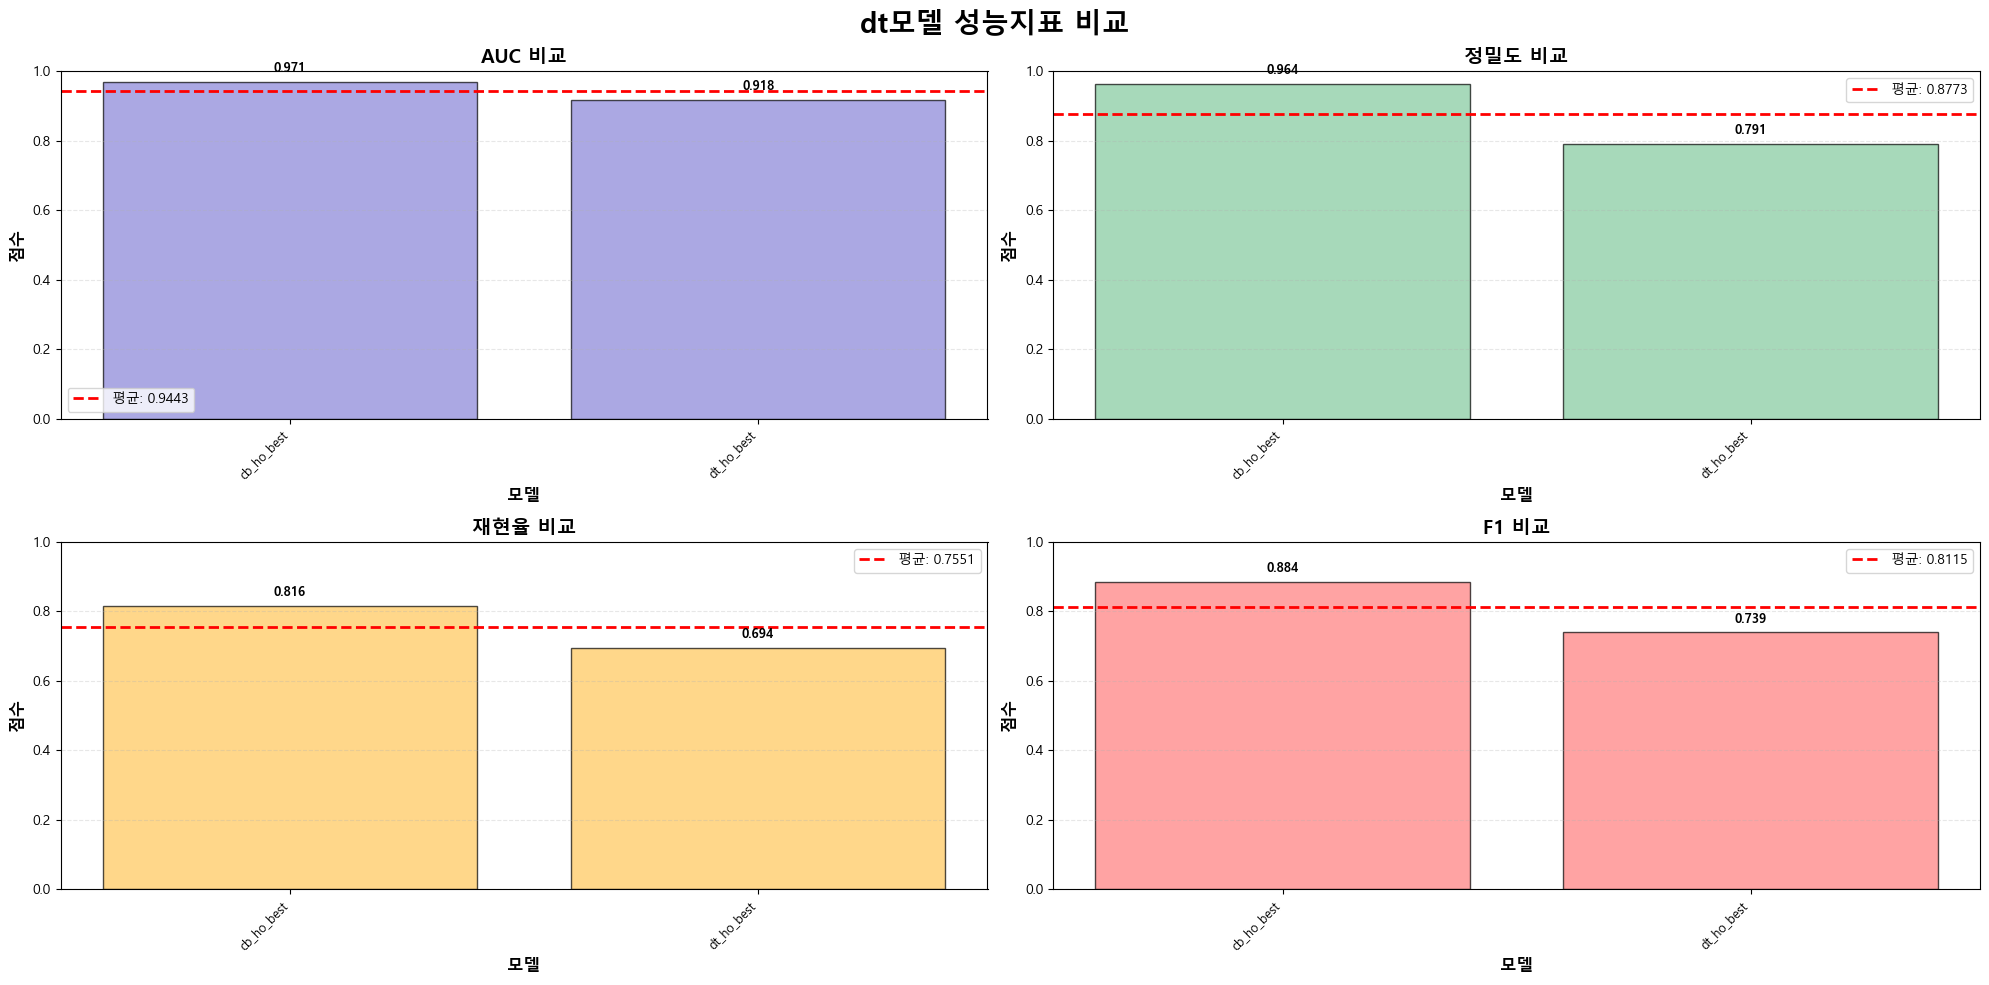


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9707 (cb_ho_best)
  최저: 0.9179 (dt_ho_best)
  평균: 0.9443
  표준편차: 0.0373

[정밀도]
  최고: 0.9639 (cb_ho_best)
  최저: 0.7907 (dt_ho_best)
  평균: 0.8773
  표준편차: 0.1225

[재현율]
  최고: 0.8163 (cb_ho_best)
  최저: 0.6939 (dt_ho_best)
  평균: 0.7551
  표준편차: 0.0865

[F1]
  최고: 0.8840 (cb_ho_best)
  최저: 0.7391 (dt_ho_best)
  평균: 0.8115
  표준편차: 0.1025


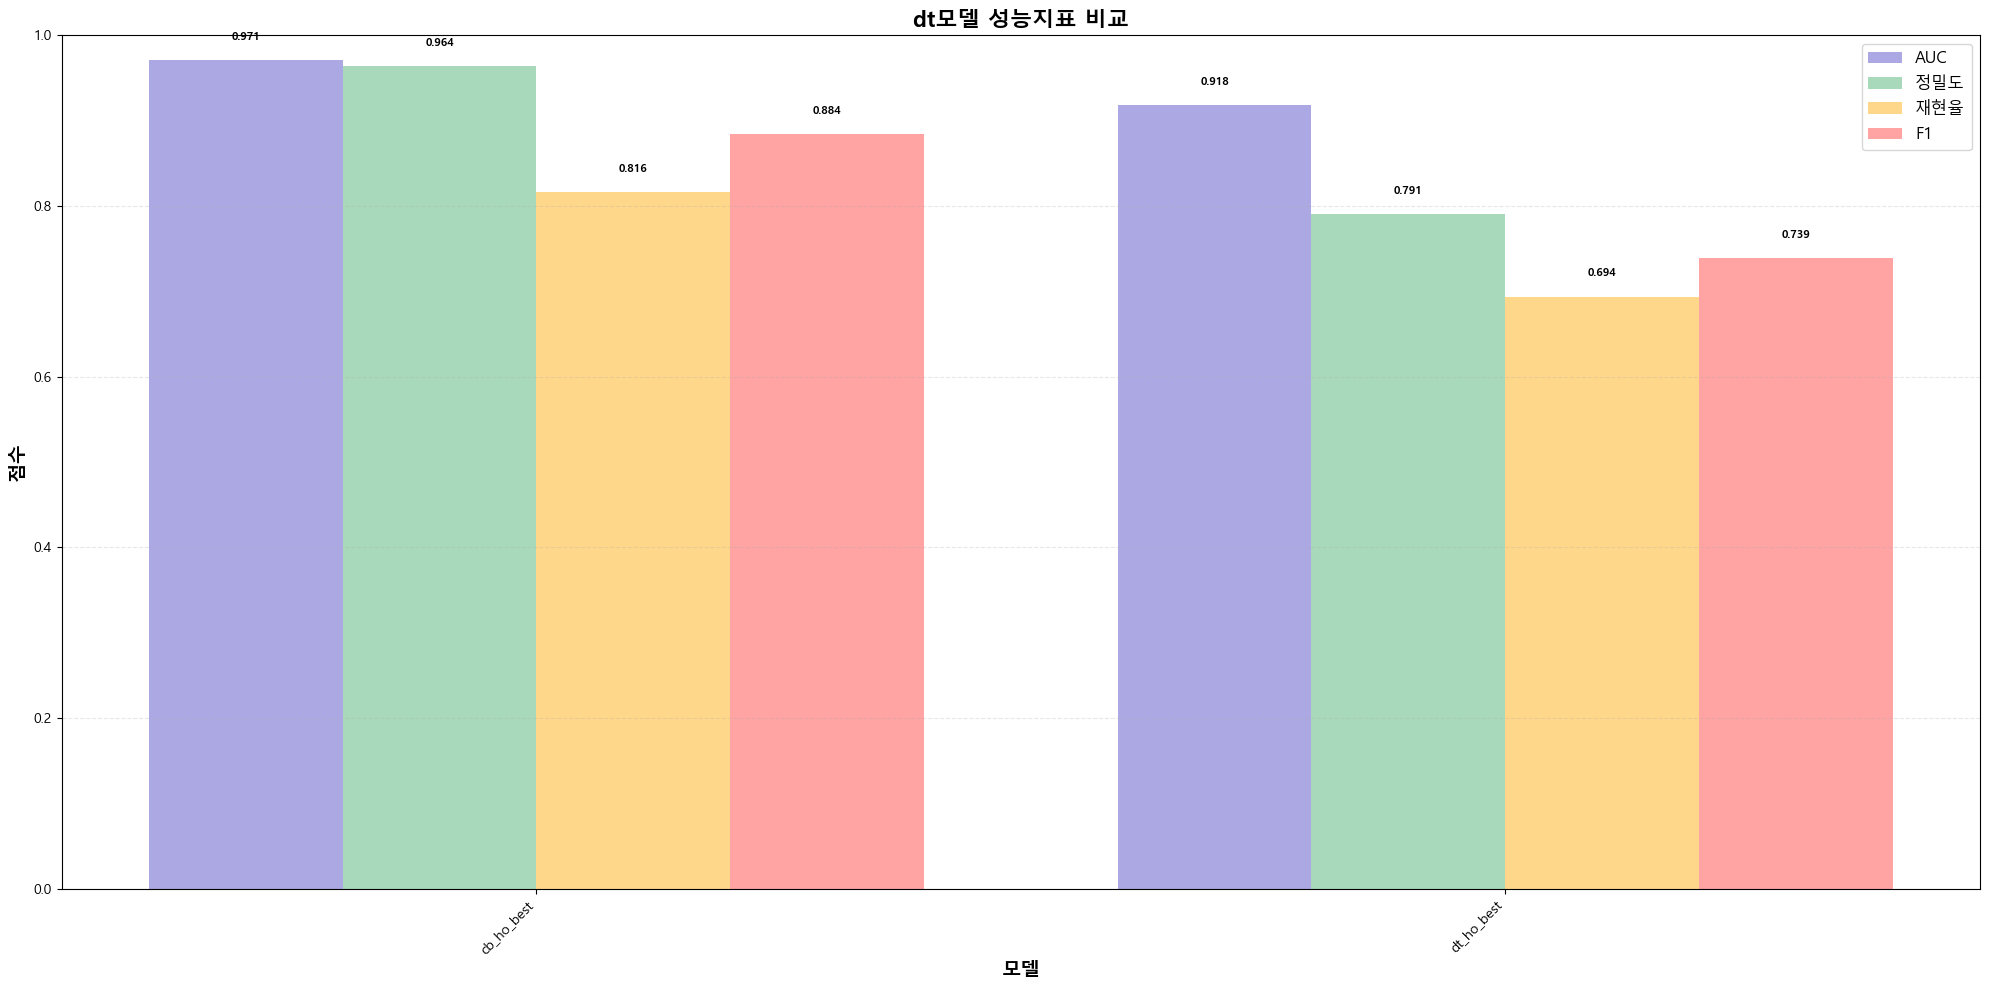


=== F1 Score 기준 상위 5개 모델 ===
               AUC     정밀도     재현율      F1
cb_ho_best  0.9707  0.9639  0.8163  0.8840
dt_ho_best  0.9179  0.7907  0.6939  0.7391

=== AUC 기준 상위 5개 모델 ===
               AUC     정밀도     재현율      F1
cb_ho_best  0.9707  0.9639  0.8163  0.8840
dt_ho_best  0.9179  0.7907  0.6939  0.7391

그래프가 저장되었습니다: ../images/dt모델_성능지표_비교_2025_1130.png


In [23]:

modeling.model_metrics_graph(results, 'dt모델 성능지표 비교')

In [12]:

X_train, X_test, y_train, y_test = preprocessing.data_split(cap_X_feature, y_target)

In [32]:

X_over, y_over = data_sampling.oversampling_smote(X_train, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [33]:
# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr_over, X_val_over, y_tr_over, y_val_over = preprocessing.data_split(X_over, y_over, size=0.4)

In [ ]:
# 2. Stacking Classifier (추천!)
from sklearn.ensemble import StackingClassifier

# Base models (다양성 확보)
base_models = [
    ('rf', RandomForestClassifier(
        random_state= 23,
        n_estimators= 390,
        max_depth= 25,
        class_weight= 'balanced',
        min_samples_leaf= 1,
        min_samples_split= 7,
        n_jobs= -1)
     ),
    ('xgb', XGBClassifier(
        colsample_bytree = 1.0,
        gamma = 1.7089112007254605,
        learning_rate = 0.038583724829444874,
        max_depth = 3,
        min_child_weight = 6,
        n_estimators = 150,
        reg_alpha = 0.5940048544595263,
        reg_lambda = 0.007186370173139192,
        scale_pos_weight = 82.0,
        subsample = 0.6,
        random_state = 23
        )
     ),
    ('lgbm', LGBMClassifier(
        random_state = 23,
        n_estimators = 400,
        num_leaves = 36,
        learning_rate = 0.03,
        subsample = 0.9,
        colsample_bytree = 0.75,
        reg_alpha = 0.6,
        reg_lambda = 0.2,
        class_weight ='balanced',
        n_jobs = -1,)
     ),
    ('gb', GradientBoostingClassifier(
        learning_rate = 0.02083271293464231, 
        max_depth = 3, 
        n_estimators = 800, 
        subsample = 0.7076395576782778, 
        random_state = 23)
     )
]

# Meta model
meta_model = LogisticRegression(class_weight='balanced')

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

model_name = 'stacking_ho-best_smote'
results[model_name] = user_utils.get_model_train_eval(
    stacking_clf, model_name, X_train, X_test, y_train, y_test, best_params
    )

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [26]:
y_pred = stacking_clf.predict(X_test)

print(f'precision: {precision_score(y_test, y_pred):.4f}\n recall: {recall_score(y_test, y_pred):.4f}\n f1-score: {f1_score(y_test, y_pred):.4f}')


precision: 0.8367
 recall: 0.8367
 f1-score: 0.8367
